
Code was assisted by Claude Code plugin in VS Code


---

## **Part 1 — Exploring Different Modalities / Representations of Network Traffic**

Synthetic network traffic generation is useful for many applications such as dataset augmentation, network testing, and resource management. Many existing generation methods treat traffic generation as either a time-series prediction task or an autoregressive modeling task. In these approaches, models are trained directly on structured representations of packets—one common example is **nPrint**, a tabular format that encodes packet header fields from PCAP traces into machine-learning-friendly numerical vectors.

In an **nPrint**, each row represents one packet in a trace. The entire nPrint file (a large CSV) represents all packets of that trace in sequential order. Header fields are encoded using one-hot–like binary indicators (e.g., `1`, `0`, or `01`), making them easy to feed into ML models.

However, general-purpose ML models—even advanced time-series architectures and transformers—often struggle to capture the *complex dependencies* present in real network traffic:

* **Local dependencies**: relationships among columns within a single row (i.e., dependencies among header fields of a single packet).
* **Global dependencies**: relationships across rows (i.e., the evolution of packets within the same flow).
  For example: if the first packet of a flow uses TCP, the second packet in that same flow should also be TCP; sequence numbers, flags, and flow identifiers evolve in structured ways over time.

While sequential ML models struggle with these multi-scale dependencies, **vision models** (e.g., diffusion models) excel at capturing both local and global structure when data is presented spatially—like an image. By converting nPrint traces into 2D PNG images, we can take advantage of the strong representational capabilities of image models and generate synthetic traffic using visual generative approaches.

---

### **Your Task for Part 1**

In this part of the assignment, you will:

1. **Inspect the raw nPrint files** (found in the `real_nprints` directory).
2. **Understand how each CSV row and column corresponds to packet-level metadata.**
3. **Follow the provided conversion pipeline** that transforms these nPrint CSVs into PNG image representations suitable for use with diffusion models and other visual architectures.
4. **Take an already generated set of image-representation of images and convert them back into nprint representation for downstream task utilization**

This will help you understand why converting network traces to images can unlock generative modeling capabilities that traditional ML approaches struggle with.

Q1:
First, download and unzip the data you will need from (https://drive.google.com/file/d/1hY6nNXEYOwl1l-O_nCknO9xezcHr6ZXi/view?usp=sharing)
In your own words, describe how an nPrint CSV encodes a network trace.
Why might a 2D image representation capture structural relationships that a row-by-row CSV cannot?

In [1]:
# Q1 (data) — download the NetDiffusion data from Google Drive and unzip it into ./nd_data
# gdown handles Google Drive's "large file" confirmation page, which plain wget/curl trips over.
import os
import zipfile
import gdown

DATA_DIR = "./nd_data"
ZIP_PATH = "./nd_data.zip"
DRIVE_FILE_ID = "1hY6nNXEYOwl1l-O_nCknO9xezcHr6ZXi"   # the id inside the share link above

if not os.path.isdir(os.path.join(DATA_DIR, "real_nprints")):
    if not os.path.exists(ZIP_PATH):
        gdown.download(id=DRIVE_FILE_ID, output=ZIP_PATH, quiet=False)
    with zipfile.ZipFile(ZIP_PATH) as zf:
        # The archive keeps real_nprints/ and generated_traffic_images/ at its top level,
        # plus macOS "__MACOSX" metadata that we skip.
        members = [m for m in zf.namelist() if not m.startswith("__MACOSX")]
        zf.extractall(DATA_DIR, members=members)

for sub in sorted(os.listdir(DATA_DIR)):
    if os.path.isdir(os.path.join(DATA_DIR, sub)):
        n_files = sum(not f.startswith(".") for f in os.listdir(os.path.join(DATA_DIR, sub)))
        print(f"{sub}: {n_files} files")


color_corrected_generated_traffic_images: 100 files
generated_nprint: 100 files
generated_traffic_images: 100 files
real_nprints: 200 files
real_traffic_images: 200 files
student_converted_images: 200 files


In [2]:
# Q1 (explore) — what do the rows and columns of one nPrint hold?
import numpy as np
import pandas as pd

sample_path = "./nd_data/real_nprints/amazon_1024.nprint"
nprint = pd.read_csv(sample_path, index_col=0)   # the unnamed first column is only a packet counter

print(f"{nprint.shape[0]} rows (one per packet) x {nprint.shape[1]} columns (one per header bit)")
print("Values that appear in the cells:", sorted(pd.unique(nprint.values.ravel()).tolist()))

# Column names follow <protocol>_<field>_<bit position>; e.g. ipv4_ttl_3 is bit 3 of the IPv4 TTL.
field_of_col = nprint.columns.str.rsplit("_", n=1).str[0]
protocol_of_col = nprint.columns.str.split("_").str[0]
print("\nBits reserved per protocol header:")
print(pd.Series(protocol_of_col).value_counts(sort=False).to_string())
print("\nBits reserved per header field:")
print(pd.Series(field_of_col).value_counts(sort=False).to_string())


1024 rows (one per packet) x 1088 columns (one per header bit)
Values that appear in the cells: [-1, 0, 1]

Bits reserved per protocol header:
ipv4    416
ipv6     64
tcp     480
udp      64
icmp     64

Bits reserved per header field:
ipv4_ver        4
ipv4_hl         4
ipv4_tos        8
ipv4_tl        16
ipv4_id        16
ipv4_rbit       1
ipv4_dfbit      1
ipv4_mfbit      1
ipv4_foff      13
ipv4_ttl        8
ipv4_proto      8
ipv4_cksum     16
ipv4_opt      320
ipv6_ver        4
ipv6_tc         8
ipv6_fl        20
ipv6_len       16
ipv6_nh         8
ipv6_hl         8
tcp_sprt       16
tcp_dprt       16
tcp_seq        32
tcp_ackn       32
tcp_doff        4
tcp_res         3
tcp_ns          1
tcp_cwr         1
tcp_ece         1
tcp_urg         1
tcp_ackf        1
tcp_psh         1
tcp_rst         1
tcp_syn         1
tcp_fin         1
tcp_wsize      16
tcp_cksum      16
tcp_urp        16
tcp_opt       320
udp_sport      16
udp_dport      16
udp_len        16
udp_cksum      16
icmp_typ

In [3]:
# Q1 (explore) — rebuild a few header fields from their bits for the first packets.
# Shows how bits map back to real header values, and how -1 marks a header the packet does not have.
def field_value(packet, field):
    """Integer value of one header field for one packet, or None if the field is absent (all -1)."""
    bits = packet[field_of_col == field].to_numpy()
    if (bits == -1).all():
        return None
    return int("".join(str(b) for b in bits), 2)

show_fields = ["ipv4_ver", "ipv4_hl", "ipv4_tl", "ipv4_ttl", "ipv4_proto",
               "tcp_sprt", "tcp_dprt", "tcp_doff", "tcp_syn", "tcp_ackf", "udp_sport"]
decoded = pd.DataFrame([{f: field_value(nprint.iloc[i], f) for f in show_fields} for i in range(8)])
decoded.index.name = "packet"
print(decoded.to_string())

print("\nShare of cells that are -1 (not present), per protocol block:")
print((nprint == -1).T.groupby(protocol_of_col, sort=False).mean().mean(axis=1).round(3).to_string())


        ipv4_ver  ipv4_hl  ipv4_tl  ipv4_ttl  ipv4_proto  tcp_sprt  tcp_dprt  tcp_doff  tcp_syn  tcp_ackf udp_sport
packet                                                                                                             
0              4        5       60        64           6     58922       443        10        1         0      None
1              4        5       60       238           6       443     58922        10        1         1      None
2              4        5       52        64           6     58922       443         8        0         1      None
3              4        5      569        64           6     58922       443         8        0         1      None
4              4        5       52       238           6       443     58922         8        0         1      None
5              4        5      208       238           6       443     58922         8        0         1      None
6              4        5       52        64           6     58922      

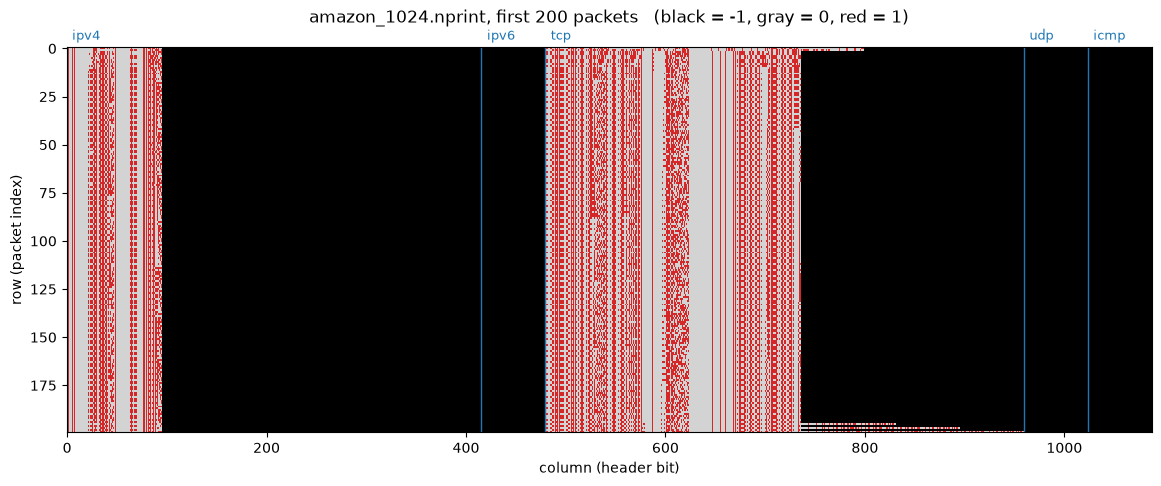

In [4]:
# Q1 (explore) — the same trace drawn as a 2D grid: rows = packets over time, columns = header bits.
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

n_show = 200
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(nprint.iloc[:n_show].to_numpy(), aspect="auto", interpolation="nearest",
          cmap=ListedColormap(["black", "lightgray", "tab:red"]), vmin=-1, vmax=1)
block_starts = pd.Series(np.arange(len(protocol_of_col)), index=protocol_of_col).groupby(level=0, sort=False).min()
for proto, col in block_starts.items():
    ax.axvline(col - 0.5, color="tab:blue", lw=1)
    ax.text(col + 5, -3, proto, color="tab:blue", fontsize=9, va="bottom")
ax.set_xlabel("column (header bit)")
ax.set_ylabel("row (packet index)")
ax.set_title(f"{os.path.basename(sample_path)}, first {n_show} packets   (black = -1, gray = 0, red = 1)", pad=18)
plt.show()


**Q1 answer**

An nPrint is a table in which each row is a packet, in capture order, and each column is a fixed bit position of a protocol header (e.g. `ipv4_ttl_3`). Every supported header (IPv4, IPv6, TCP, UDP, ICMP) always has its columns. A cell is `1` or `0` if that bit exists in the packet and `-1` if it does not, so the same column means the same thing in every packet and every trace.

A CSV presents packets as separate rows or one flattened vector, so a model must learn from scratch which columns belong together. In an image, bits of the same field are horizontal neighbours (local dependencies within a packet), and the same field across packets forms a vertical line (global dependencies across the flow). The information is identical, but the image lays this structure out spatially, which is what vision models are designed to learn.


Q2. Design a method for converting nPrint representations of traces (in the folder real_nprints) into image representations.
Your image representation should use only the first 1024 packets from each trace to avoid producing images that are too large.
Save the images into a folder called './nd_data/student_converted_images'

In [5]:
# Q2 — my nPrint -> image conversion
#
# Design choices:
#  * One pixel per (packet, header bit): pixel row y = packet y, pixel column x = header bit x.
#    Keeping the nPrint grid intact means horizontal neighbours are bits of the same field in one packet
#    (local structure) and vertical neighbours are the same bit in consecutive packets (global structure).
#  * Drop the CSV's unnamed index column: it is a packet counter, not packet data.
#  * Keep only the first 1024 packets; shorter traces are padded with -1 ("no packet") so every image has
#    the same 1024-row height, which a generative model needs.
#  * Encode the three symbols as grayscale intensities: -1 -> 0 (black), 0 -> 128 (gray), 1 -> 255 (white).
#    One 8-bit channel is enough to hold three symbols.
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

MAX_PACKETS = 1024
GRAY_LEVELS = np.array([0, 128, 255], dtype=np.uint8)   # intensity for -1, 0, 1  (array index = value + 1)

def nprint_to_gray_image(nprint_path, max_packets=MAX_PACKETS):
    bits = pd.read_csv(nprint_path, index_col=0).to_numpy(dtype=np.int8)[:max_packets]
    grid = np.full((max_packets, bits.shape[1]), -1, dtype=np.int8)   # pad missing packets with -1
    grid[: len(bits)] = bits
    return Image.fromarray(GRAY_LEVELS[grid + 1])                     # lookup table: value -> intensity

def gray_image_to_bits(img):
    """Inverse mapping: snap every pixel to the nearest gray level, then recover -1 / 0 / 1."""
    pixels = np.asarray(img, dtype=np.int16)[..., None]
    return np.abs(pixels - GRAY_LEVELS.astype(np.int16)).argmin(axis=-1) - 1

in_dir = "./nd_data/real_nprints"
out_dir = "./nd_data/student_converted_images"
os.makedirs(out_dir, exist_ok=True)

nprint_paths = sorted(glob.glob(os.path.join(in_dir, "*.nprint")))
for path in nprint_paths:
    img = nprint_to_gray_image(path)
    img.save(os.path.join(out_dir, os.path.basename(path).replace(".nprint", ".png")))

print(f"Converted {len(nprint_paths)} nPrints into {out_dir} (each {img.size[0]} x {img.size[1]} px, mode {img.mode})")


Converted 200 nPrints into ./nd_data/student_converted_images (each 1088 x 1024 px, mode L)


Bits that differ after nPrint -> image -> nPrint: 0


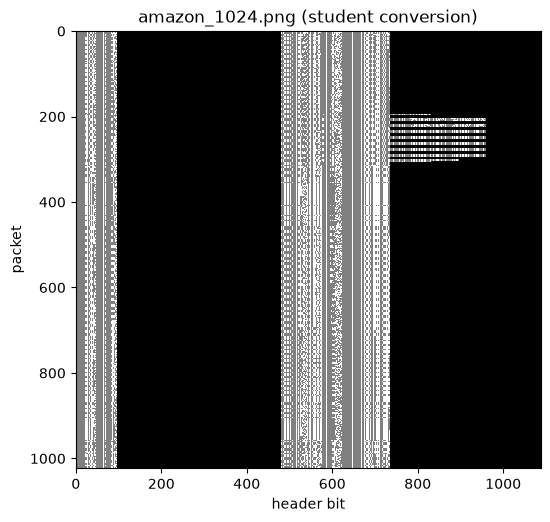

In [6]:
# Q2 (check) — the conversion should be lossless: decode each image and compare it with its source nPrint.
mismatched_bits = 0
for path in nprint_paths:
    original = pd.read_csv(path, index_col=0).to_numpy()[:MAX_PACKETS]
    img = Image.open(os.path.join(out_dir, os.path.basename(path).replace(".nprint", ".png")))
    mismatched_bits += int((gray_image_to_bits(img)[: len(original)] != original).sum())
print("Bits that differ after nPrint -> image -> nPrint:", mismatched_bits)

example = Image.open(os.path.join(out_dir, "amazon_1024.png"))
plt.figure(figsize=(6, 6))
plt.imshow(example, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
plt.title("amazon_1024.png (student conversion)")
plt.xlabel("header bit")
plt.ylabel("packet")
plt.show()


**Q2 answer**

Each nPrint cell becomes one grayscale pixel in the original grid (row = packet, column = header bit), so the structure from Q1 is preserved. I drop the index column because it is a packet counter rather than packet data, keep the first 1024 packets, and pad shorter traces with `-1`, so every image is 1088 × 1024. Values map as `-1` → black, `0` → gray and `1` → white. The mapping is exactly reversible, as the check cell confirms (0 bits differ).


In [7]:
# The following is a pre-defined script used in NetDiffusion that will convert all of the provided real nprints into image representations. Run this code and observe the output
!python ./scripts/nprint_to_png.py -i ./nd_data/real_nprints/ -o ./nd_data/real_traffic_images

Processing teams_1024_10.nprint
/Users/erniemok/Downloads/projects/ml-systems/docs/assignments/./scripts/nprint_to_png.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  np_df = np.array(df.applymap(np.array).to_numpy().tolist())
Processing twitch_1024_7.nprint
/Users/erniemok/Downloads/projects/ml-systems/docs/assignments/./scripts/nprint_to_png.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  np_df = np.array(df.applymap(np.array).to_numpy().tolist())
Processing netflix_1024_15.nprint
/Users/erniemok/Downloads/projects/ml-systems/docs/assignments/./scripts/nprint_to_png.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  np_df = np.array(df.applymap(np.array).to_numpy().tolist())
Processing twitter_1024_17.nprint
/Users/erniemok/Downloads/projects/ml-systems/docs/assignments/./scripts/nprint_to_png.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use D

Q3: Now that you have seen how NetDiffusion converts nPrints into images, compare their method with the approach you designed in Q2. What are the advantages and disadvantages of each, especially in terms of what might help or hinder a vision model’s ability to learn?

     student: 1088 x 1024 px, mode L, 32 KB on disk
NetDiffusion: 1089 x 1024 px, mode RGBA, 68 KB on disk
NetDiffusion image columns whose alpha is not 255: [0]


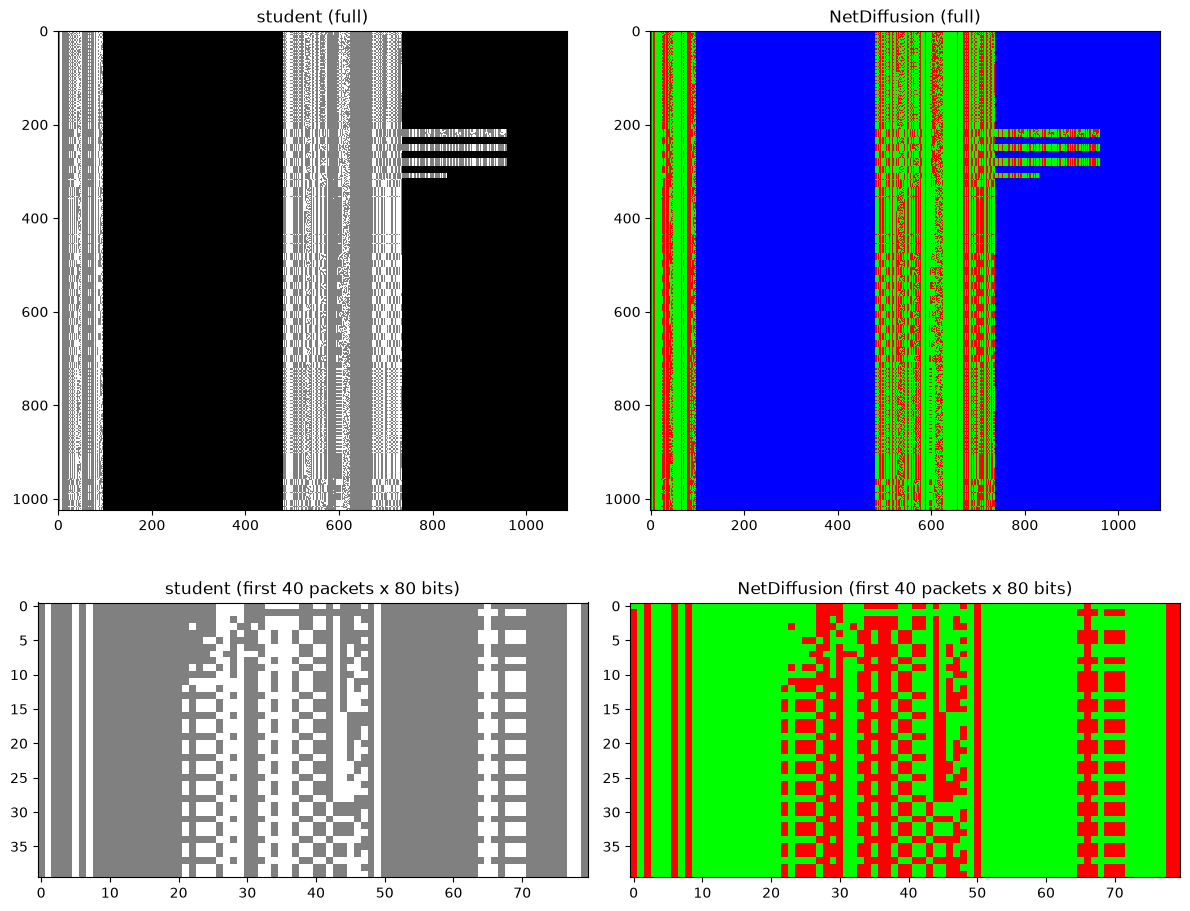

     student (gray) distance between symbols: {'-1 vs 0': 128.0, '0 vs 1': 127.0, '-1 vs 1': 255.0}
 NetDiffusion (RGB) distance between symbols: {'-1 vs 0': 360.6, '0 vs 1': 360.6, '-1 vs 1': 360.6}


In [8]:
# Q3 (support) — the two representations of the same trace, side by side.
name = "amazon_1024"
paths = {"student": f"./nd_data/student_converted_images/{name}.png",
         "NetDiffusion": f"./nd_data/real_traffic_images/{name}.png"}
imgs = {k: Image.open(p) for k, p in paths.items()}
for k, img in imgs.items():
    print(f"{k:>12}: {img.size[0]} x {img.size[1]} px, mode {img.mode}, {os.path.getsize(paths[k]) / 1024:.0f} KB on disk")

# NetDiffusion also uses the alpha channel (for values other than -1/0/1). Where is alpha not 255 here?
alpha = np.asarray(imgs["NetDiffusion"])[..., 3]
print("NetDiffusion image columns whose alpha is not 255:", np.unique(np.where(alpha != 255)[1]))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
student_px = np.asarray(imgs["student"])
nd_px = np.asarray(imgs["NetDiffusion"].convert("RGB"))
axes[0, 0].imshow(student_px, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[0, 1].imshow(nd_px, interpolation="nearest")
axes[1, 0].imshow(student_px[:40, :80], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[1, 1].imshow(nd_px[:40, :80], interpolation="nearest")
for ax, title in zip(axes.ravel(), ["student (full)", "NetDiffusion (full)",
                                     "student (first 40 packets x 80 bits)", "NetDiffusion (first 40 packets x 80 bits)"]):
    ax.set_title(title)
plt.tight_layout()
plt.show()

# How far apart are the three symbols in each colour space? A bigger gap tolerates more pixel noise
# before one symbol gets mistaken for another.
codes = {"student (gray)": {-1: [0], 0: [128], 1: [255]},
         "NetDiffusion (RGB)": {-1: [0, 0, 255], 0: [0, 255, 0], 1: [255, 0, 0]}}
for label, c in codes.items():
    gaps = {f"{a} vs {b}": round(float(np.linalg.norm(np.subtract(c[a], c[b]))), 1) for a, b in [(-1, 0), (0, 1), (-1, 1)]}
    print(f"{label:>19} distance between symbols: {gaps}")


**Q3 answer**

Both methods use one pixel per packet bit and 1024 rows; they differ in how the three values are encoded. NetDiffusion uses red, green and blue (with alpha for other values), while mine uses three gray levels.

- **NetDiffusion, advantages:** the three colours are far apart and equally distant from each other, so noisy generated pixels can still be decoded, and the RGB format matches what Stable Diffusion is pretrained on.
- **NetDiffusion, disadvantages:** it keeps the CSV index column, giving 1089-wide images with a column of non-packet data, and it relies on alpha, which the RGB-only diffusion model cannot reproduce.
- **Mine, advantages:** compact and exactly lossless, with only packet data.
- **Mine, disadvantages:** gray sits close to both black and white, so small errors flip values. The brightness order also implies `-1 < 0 < 1`, so a blend of "absent" and `1` reads as `0`.

Mine is the better storage format, but NetDiffusion's is better for training a vision model and decoding its output.



---

## **Part 2 — Converting Generated Images Back Into Usable Format**

In the first part of the assignment, you explored how network traces in nPrint format can be transformed into image representations suitable for vision-based generative models. In Part 2, we focus on the reverse process: taking synthetic images produced by these models and converting them back into structured network representations.

This step is crucial because real-world applications do not operate on images—they require valid, interpretable packet traces that can be analyzed, replayed, or integrated into downstream tools.

---

### **Your Task for Part 2**

In this part of the assignment, you will:

1. **Convert generated images back into the original nPrint representation.**
   You will follow a scripted pipeline that translates pixel intensities and color channels back into binary header fields, reconstructing the packet-level structure of the trace.

2. **Apply essential post-processing techniques to correct errors introduced by diffusion models.**
   Generated images are rarely perfect—vision models may introduce color drift, pixel misalignment, noise, or structural artifacts.
   You will observe how heuristic correction, formatting enforcement, and reconstruction steps ensure that the converted nPrints become:

   * syntactically valid,
   * structurally consistent,
   * and replayable.

Across this section, your goal is to understand **why the reverse transformation is fragile**, which types of artifacts break reversibility, and how post-processing logic helps repair or compensate for generative errors.

For simplicity of this assignment, we have trainined and generated the images for you. If you have sufficient GPU access and want to try fine-tuning the model and generating the images yourself, feel free to take a look at the public repo (https://github.com/noise-lab/NetDiffusion).


Q4: We have taken the images converted by NetDiffusion and trained a LoRA-fine-tuned Stable Diffusion model (with ControlNet) to generate synthetic traffic images for you. These generated samples are stored in generated_traffic_images/.
Compare these generated images visually with the real images you saw earlier in real_traffic_images/.

Do you notice anything different between the real and generated traffic images? What immediately stands out as potentially problematic if we attempt to convert these generated images back into nPrint format? (Descriptive Only)

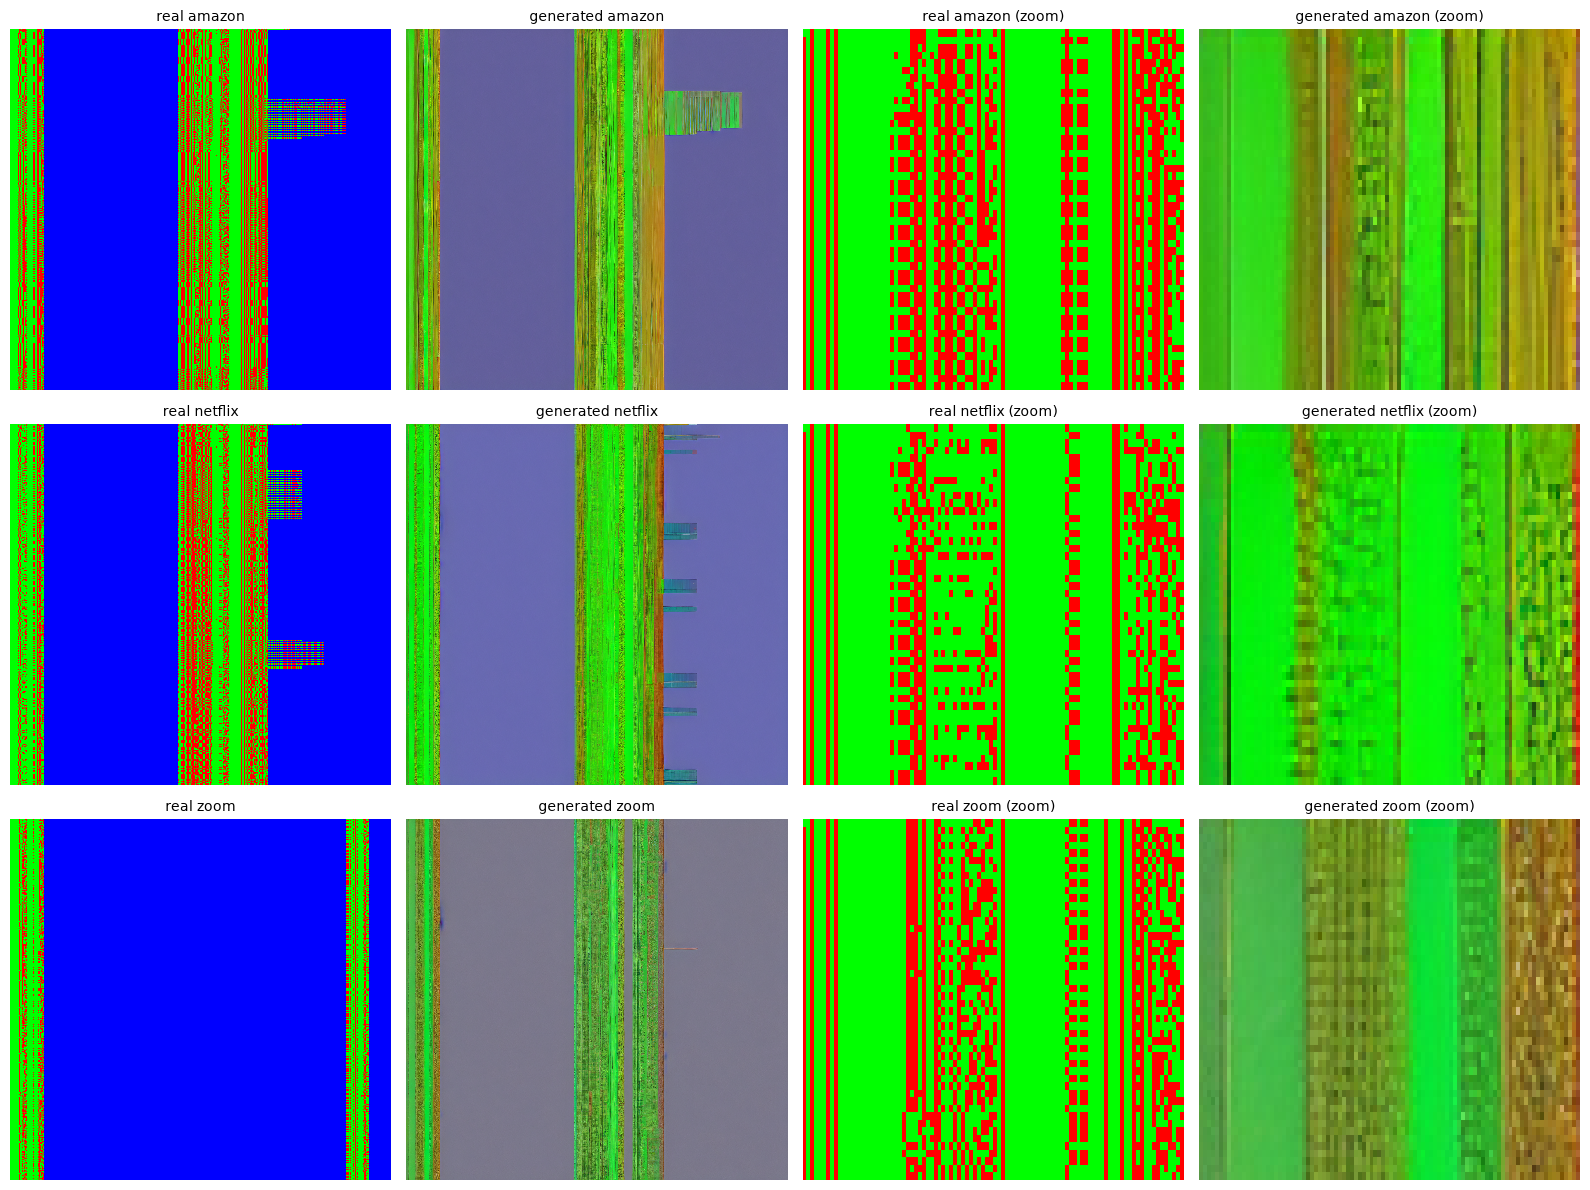

In [9]:
# Q4 (support) — real vs generated images for a few applications: full view and a zoom on the top-left corner.
apps = ["amazon", "netflix", "zoom"]
fig, axes = plt.subplots(len(apps), 4, figsize=(16, 4 * len(apps)))
for r, app in enumerate(apps):
    real = np.asarray(Image.open(f"./nd_data/real_traffic_images/{app}_1024.png").convert("RGB"))
    gen = np.asarray(Image.open(f"./nd_data/generated_traffic_images/{app}_0.png").convert("RGB"))
    panels = [(real, f"real {app}"), (gen, f"generated {app}"),
              (real[:48, :96], f"real {app} (zoom)"), (gen[:48, :96], f"generated {app} (zoom)")]
    for c, (img, title) in enumerate(panels):
        axes[r, c].imshow(img, aspect="auto", interpolation="nearest")
        axes[r, c].set_title(title, fontsize=10)
        axes[r, c].axis("off")
plt.tight_layout()
plt.show()


In [10]:
# Q4 (support) — put numbers on what the eye sees.
import hashlib

PALETTE = np.array([[0, 0, 255], [0, 255, 0], [255, 0, 0]], dtype=np.int32)   # NetDiffusion colours for -1, 0, 1

def colour_stats(path):
    img = Image.open(path)
    rgb = np.asarray(img.convert("RGB"), dtype=np.int32)
    dist = np.sqrt(((rgb[:, :, None, :] - PALETTE[None, None]) ** 2).sum(axis=-1)).min(axis=-1)
    return {"image": os.path.basename(path), "size (w x h)": img.size, "mode": img.mode,
            "distinct colours": len(np.unique(rgb.reshape(-1, 3), axis=0)),
            "pixels exactly on palette": round(float((dist == 0).mean()), 3),
            "mean distance to nearest palette colour": round(float(dist.mean()), 1)}

stats = [colour_stats(f"./nd_data/real_traffic_images/{app}_1024.png") for app in apps] + \
        [colour_stats(f"./nd_data/generated_traffic_images/{app}_0.png") for app in apps]
print(pd.DataFrame(stats).to_string(index=False))

# Are the generated samples actually different from each other?
generated_paths = sorted(glob.glob("./nd_data/generated_traffic_images/*.png"))
digests = pd.Series({os.path.basename(p): hashlib.md5(open(p, "rb").read()).hexdigest() for p in generated_paths})
print(f"\n{len(generated_paths)} generated images, {digests.nunique()} byte-for-byte unique")
print("Unique generated images per app:",
      digests.groupby(digests.index.str.split("_").str[0]).nunique().to_dict())


           image size (w x h) mode  distinct colours  pixels exactly on palette  mean distance to nearest palette colour
 amazon_1024.png (1089, 1024) RGBA                 3                        1.0                                      0.0
netflix_1024.png (1089, 1024) RGBA                 3                        1.0                                      0.0
   zoom_1024.png (1089, 1024) RGBA                 3                        1.0                                      0.0
    amazon_0.png (1088, 1024)  RGB            298474                        0.0                                    159.4
   netflix_0.png (1088, 1024)  RGB            254939                        0.0                                    142.6
      zoom_0.png (1088, 1024)  RGB            251362                        0.0                                    187.1

100 generated images, 45 byte-for-byte unique
Unique generated images per app: {'amazon': 6, 'facebook': 3, 'instagram': 5, 'meet': 4, 'netflix': 4, 'te

**Q4 answer**

Real images contain exactly three pure colours in sharp pixel patterns. Generated images are blurry and full of in-between colours: absent regions are purple-gray instead of blue, and bits appear as olive or yellow mixtures of red and green. The overall stripe layout looks right but the details do not, and many generated images are duplicates.

This is a problem for converting back because:
1. Pixels no longer map exactly to a value, so a decoder has to guess, especially for colours between red and green.
2. Even after snapping colours, packets can break protocol rules, e.g. partially present fields, a wrong IP version, or options that do not match the header length.
3. Blurred boundaries can shift where header fields start and end.


Q5: If you were to design a method to convert generated images back into nPrints, how would you do it? Explain your approach and describe how your method addresses the concerns you raised in Q4. (Descriptive only)

In [11]:
# Q5 (optional prototype) — one possible image -> nPrint decoder, to back up the written answer.
# Idea: (1) decode colours by *nearest* palette colour rather than exact matches or fixed thresholds;
#       (2) repair the decoded bits with rules every valid packet header must satisfy;
#       (3) measure validity with those same rules, so "before vs after repair" can be compared.
import os
import glob
import numpy as np
import pandas as pd
from PIL import Image

PALETTE = np.array([[0, 0, 255], [0, 255, 0], [255, 0, 0]], dtype=np.int32)   # colours for -1, 0, 1
REF_COLUMNS = pd.read_csv("./scripts/column_example.nprint", index_col=0, nrows=0).columns
FIELD_OF_COL = REF_COLUMNS.str.rsplit("_", n=1).str[0].to_numpy()
FIELD_IDX = {f: np.flatnonzero(FIELD_OF_COL == f) for f in pd.unique(FIELD_OF_COL)}
OPTION_FIELDS = {"ipv4_opt", "tcp_opt"}                 # variable length, governed by ipv4_hl / tcp_doff
HEADERS = ["ipv4", "ipv6", "tcp", "udp", "icmp"]
HEADER_COLS = {h: np.concatenate([c for f, c in FIELD_IDX.items() if f.startswith(h + "_") and f not in OPTION_FIELDS])
               for h in HEADERS}
PROTO_NUMBER = {"tcp": 6, "udp": 17, "icmp": 1}


def field_int(bits, field):
    """Integer value of a header field for every packet (absent bits count as 0)."""
    b = np.clip(bits[:, FIELD_IDX[field]], 0, 1).astype(np.int64)
    return b @ (1 << np.arange(b.shape[1] - 1, -1, -1))


def decode_nearest_colour(img_path):
    rgb = np.asarray(Image.open(img_path).convert("RGB"), dtype=np.int32)
    dist = ((rgb[:, :, None, :] - PALETTE[None, None]) ** 2).sum(axis=-1)
    return dist.argmin(axis=-1).astype(np.int8) - 1, rgb      # palette index 0/1/2 -> -1/0/1


def repair(bits, rgb):
    bits = bits.copy()
    guess01 = (rgb[..., 0] > rgb[..., 1]).astype(np.int8)     # "more red than green" -> 1, else 0

    def make_present(rows, cols):
        sub = bits[np.ix_(rows, cols)]
        bits[np.ix_(rows, cols)] = np.where(sub == -1, guess01[np.ix_(rows, cols)], sub)

    # Which headers does each packet (row) carry? Majority vote over each header's bits.
    share = {h: (bits[:, c] != -1).mean(axis=1) for h, c in HEADER_COLS.items()}
    is_packet = np.maximum(share["ipv4"], share["ipv6"]) > 0.5          # otherwise: a padding row
    net = np.where(share["ipv4"] >= share["ipv6"], "ipv4", "ipv6")
    transport = np.array(["tcp", "udp", "icmp"])[np.argmax([share["tcp"], share["udp"], share["icmp"]], axis=0)]

    # Rule 1: a header is all-or-nothing. Kept headers get every fixed bit, the rest become -1.
    for h in HEADERS:
        keep = is_packet & ((net == h) | (transport == h))
        bits[np.ix_(~keep, HEADER_COLS[h])] = -1
        make_present(np.flatnonzero(keep), HEADER_COLS[h])

    # Rule 2: IPv4 version is 4, and ipv4_proto must name the transport header we kept.
    v4 = np.flatnonzero(is_packet & (net == "ipv4"))
    bits[np.ix_(v4, FIELD_IDX["ipv4_ver"])] = [0, 1, 0, 0]
    proto = np.array([PROTO_NUMBER[t] for t in transport[v4]], dtype=np.int64)
    bits[np.ix_(v4, FIELD_IDX["ipv4_proto"])] = (proto[:, None] >> np.arange(7, -1, -1)) & 1

    # Rule 3: option bits present exactly up to the length implied by the header-length field.
    for hdr, len_field, opt_field in [("ipv4", "ipv4_hl", "ipv4_opt"), ("tcp", "tcp_doff", "tcp_opt")]:
        has_hdr = is_packet & ((net == hdr) | (transport == hdr))
        n_opt_bits = np.where(has_hdr, np.clip(field_int(bits, len_field) * 32 - 160, 0, 320), 0)
        cols = FIELD_IDX[opt_field]
        inside = np.arange(len(cols))[None, :] < n_opt_bits[:, None]
        sub = bits[:, cols]
        bits[:, cols] = np.where(inside, np.where(sub == -1, guess01[:, cols], sub), -1)
    return bits


def validity_report(bits):
    """Fraction of packets (rows) that satisfy each structural rule."""
    present = {h: (bits[:, c] != -1).any(axis=1) for h, c in HEADER_COLS.items()}
    is_packet = present["ipv4"] | present["ipv6"]
    whole_fields = np.ones(len(bits), dtype=bool)
    for f, c in FIELD_IDX.items():
        if f not in OPTION_FIELDS:
            whole_fields &= (bits[:, c] == -1).all(axis=1) | (bits[:, c] != -1).all(axis=1)
    n_transport = present["tcp"].astype(int) + present["udp"] + present["icmp"]
    proto = field_int(bits, "ipv4_proto")
    proto_ok = ~present["ipv4"] | np.any([present[t] & (proto == n) for t, n in PROTO_NUMBER.items()], axis=0)
    opts_ok = np.ones(len(bits), dtype=bool)
    for hdr, len_field, opt_field in [("ipv4", "ipv4_hl", "ipv4_opt"), ("tcp", "tcp_doff", "tcp_opt")]:
        n_opt_bits = np.where(present[hdr], np.clip(field_int(bits, len_field) * 32 - 160, 0, 320), 0)
        should = np.arange(len(FIELD_IDX[opt_field]))[None, :] < n_opt_bits[:, None]
        opts_ok &= ((bits[:, FIELD_IDX[opt_field]] != -1) == should).all(axis=1)
    padding = ~is_packet & (bits == -1).all(axis=1)
    return {
        "fields all-or-nothing": whole_fields.mean(),
        "one network header": ((present["ipv4"] ^ present["ipv6"]) | padding).mean(),
        "one transport header": ((is_packet & (n_transport == 1)) | padding).mean(),
        "ipv4_proto matches": proto_ok.mean(),
        "option length matches": opts_ok.mean(),
    }


In [12]:
# Q5 (optional prototype) — does the idea hold up? Score the rules on real nPrints (should be 100%),
# on generated images decoded by nearest colour only, and after repair.
# Repaired output passes by construction; the interesting number is how many bits the repair had to change.
real_scores = [validity_report(pd.read_csv(p, index_col=0).to_numpy(dtype=np.int8))
               for p in sorted(glob.glob("./nd_data/real_nprints/*.nprint"))]
raw_scores, repaired_scores, changed = [], [], []
for p in sorted(glob.glob("./nd_data/generated_traffic_images/*.png")):
    bits, rgb = decode_nearest_colour(p)
    fixed = repair(bits, rgb)
    raw_scores.append(validity_report(bits))
    repaired_scores.append(validity_report(fixed))
    changed.append((fixed != bits).mean())

print(pd.DataFrame({"real nPrints": pd.DataFrame(real_scores).mean(),
                    "generated, nearest colour": pd.DataFrame(raw_scores).mean(),
                    "generated, repaired": pd.DataFrame(repaired_scores).mean()}).round(3).to_string())
print(f"\nShare of bits changed by the repair step: {np.mean(changed):.3%}")


                       real nPrints  generated, nearest colour  generated, repaired
fields all-or-nothing           1.0                      0.275                  1.0
one network header              1.0                      0.875                  1.0
one transport header            1.0                      0.995                  1.0
ipv4_proto matches              1.0                      0.017                  1.0
option length matches           1.0                      0.240                  1.0

Share of bits changed by the repair step: 6.108%


**Q5 answer**

1. **Decode each pixel to its nearest palette colour** (red, green or blue) instead of requiring exact matches. This handles colour drift and blur.
2. **Repair each packet with protocol rules:**
   - Pick one network header and one transport header by majority vote.
   - Make the chosen headers fully present and set all others to `-1`.
   - Fix fields implied by other fields: IP version = 4, `ipv4_proto` matches the transport header, and option length matches `ipv4_hl`/`tcp_doff`.
3. **Recompute checksums and lengths** when writing PCAPs, since the image cannot produce them correctly.

Step 1 addresses the ambiguous colours from Q4, and step 2 addresses invalid packets and shifted fields. The limitation is that this guarantees well-formed packets, not realistic values; ports or sequence numbers can still be wrong.


Below are a set of pre-written scripts that perform the necessary post-generation augmentation and processing on the synthetic images you obtained from the diffusion model. These scripts handle tasks such as color normalization/augmentation and conversion from generated images back into nPrint format.
(The PCAP step is optional — you may run it if you are interested in observing or replaying the reconstructed traffic.)

In [13]:
# Step 1: Color Augmentation
!python ./scripts/color_processor.py \
  --input_dir="./nd_data/generated_traffic_images" \
  --output_dir="./nd_data/color_corrected_generated_traffic_images"

Processed 100 images.


In [14]:
# Step 2: Image-to-nPrint Conversion
!python ./scripts/image_to_nprint.py \
  --org_nprint ./scripts/column_example.nprint \
  --input_dir ./nd_data/color_corrected_generated_traffic_images \
  --output_dir ./nd_data/generated_nprint

Processing ./nd_data/color_corrected_generated_traffic_images/teams_5.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/teams_5.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/twitch_3.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/twitch_3.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/zoom_7.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/zoom_7.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/zoom_6.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/zoom_6.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/twitch_2.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/twitch_2.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/teams_4.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/teams_4.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/teams_6.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/teams_6

Q6: You may now read through the provided scripts in color_processor.py (color augmentation / normalization) and image_to_nprint.py (image → nPrint reconstruction).
How do the post-processing methods implemented in these scripts compare to the approach you proposed in Q5?
Describe the pros and cons of both methods and highlight any differences in design philosophy, robustness, or assumptions.

In [15]:
# Q6 (support) — score the provided pipeline's nPrints (./nd_data/generated_nprint) with the same rules,
# and compare its decoded bits with the Q5 prototype on the same generated images.
rows = []
for img_path in sorted(glob.glob("./nd_data/generated_traffic_images/*.png")):
    name = os.path.basename(img_path).replace(".png", "")
    provided_df = pd.read_csv(f"./nd_data/generated_nprint/{name}.nprint", index_col=0)
    provided = provided_df.fillna(-1).to_numpy(dtype=np.int8)
    nearest, rgb = decode_nearest_colour(img_path)
    repaired = repair(nearest, rgb)
    rows.append({"pixels the provided script could not map (NaN)": provided_df.isna().to_numpy().mean(),
                 **{f"provided: {k}": v for k, v in validity_report(provided).items()},
                 "bits where provided == nearest colour": (provided == nearest).mean(),
                 "bits where provided == repaired": (provided == repaired).mean()})
print(pd.DataFrame(rows).mean().round(4).to_string())


pixels the provided script could not map (NaN)    0.0000
provided: fields all-or-nothing                   0.2921
provided: one network header                      0.8719
provided: one transport header                    0.9934
provided: ipv4_proto matches                      0.0418
provided: option length matches                   0.1766
bits where provided == nearest colour             0.9462
bits where provided == repaired                   0.8967


In [16]:
# Q6 (support) — look at concrete pixels where colour_processor.py's thresholds and nearest-colour disagree.
img_path = "./nd_data/generated_traffic_images/amazon_0.png"
provided = pd.read_csv("./nd_data/generated_nprint/amazon_0.nprint", index_col=0).fillna(-1).to_numpy(dtype=np.int8)
nearest, rgb = decode_nearest_colour(img_path)
ys, xs = np.nonzero(provided != nearest)
print(f"{len(ys)} of {provided.size} bits disagree in amazon_0")
if len(ys):
    pick = np.random.default_rng(0).choice(len(ys), size=min(10, len(ys)), replace=False)
    print(pd.DataFrame({"column": REF_COLUMNS[xs[pick]], "packet": ys[pick],
                        "RGB": [tuple(rgb[y, x]) for y, x in zip(ys[pick], xs[pick])],
                        "provided": provided[ys[pick], xs[pick]], "nearest colour": nearest[ys[pick], xs[pick]]}).to_string(index=False))


117014 of 1114112 bits disagree in amazon_0
      column  packet            RGB  provided  nearest colour
ipv4_proto_5     854 (149, 158, 43)         1               0
tcp_cksum_10     816  (151, 159, 2)         1               0
   tcp_opt_8     630  (92, 132, 69)         1               0
   ipv4_tl_7     494  (74, 136, 10)         1               0
 tcp_dprt_12     253 (124, 138, 27)         1               0
 tcp_sprt_12      53 (111, 111, 21)         1               0
 tcp_sprt_15      23  (140, 153, 4)         1               0
   tcp_seq_8     279  (69, 107, 14)         1               0
 tcp_opt_105     194  (80, 154, 89)         1               0
  ipv4_ttl_6      95   (39, 109, 9)         1               0


**Q6 answer**

Both approaches snap pixels to three colours, but the provided pipeline stops there, while mine also enforces protocol rules.

- **Provided, pros:** simple, works for any nPrint layout without protocol knowledge, and keeps exactly what the model generated.
- **Provided, cons:**
  - The hand-set thresholds are asymmetric: the green and blue rules require `r < 0` and never fire, so green-dominant pixels often become `1`.
  - Nothing is repaired, so most packets break header rules.
- **Mine, pros:** colours are decoded without bias, and headers are always valid.
- **Mine, cons:** depends on hand-written rules for specific protocols, and forcing valid output can hide how wrong the model was.

The provided scripts decode faithfully with minimal assumptions and leave protocol fixes to PCAP reconstruction later; mine applies domain knowledge up front.



---

# **Part 3 — Using Real and Synthetic nPrints for Application Classification**

In the previous parts, you learned how network traces can be converted between nPrint and image representations, generated using diffusion models, and reconstructed back into nPrint format.
Now, you will evaluate how useful these generated nPrints are for downstream **machine learning tasks**.

Each nPrint file—whether real or generated—is labeled with the **application** that produced the traffic (e.g., `amazon_1.nprint` means this sample came from Amazon traffic).
In this section, you will treat each **entire nPrint file as a single sample** and build a simple ML pipeline to classify application labels.

To simplify the task, you will restrict your model to use **only the first 3 packets** (3 rows) from each nPrint.
This mimics “early packet classification,” where only the beginning of a flow is available.

---


Q7:

You now have access to both `real_nprints/` and `generated_nprint/`.
Notice that in both directories, files are labeled using the application associated with that nPrint (e.g., `amazon_1.nprint`).
Treat each **nPrint file** as one sample.

**Design an ML pipeline that trains a model using *synthetic nPrints* (from `generated_nprint/`) and evaluates its performance on *real nPrints* (from `real_nprints/`) to predict the correct application label.**

Your pipeline should:

1. Use only the **first 3 packets (first 3 rows)** of each nPrint file as input features.
2. Train a classifier on real data.
3. Test the classifier on generated data.
4. Report how well the classifier performs.

We have already written the script to load the real and generated nprints into DataFrame for you.

In [17]:
import os
import glob
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# Safe conversion for nPrint cell
# ---------------------------------------------------------------
def safe_convert(x):
    if pd.isna(x):
        return 0
    x = str(x).strip()

    if x in ["0", "1", "-1"]:
        return int(x)

    if all(c in "01" for c in x) and len(x) <= 16:
        return int(x, 2)

    if x.lstrip("-").isdigit():
        return int(x)

    return 0


# ---------------------------------------------------------------
# Get original column names from a reference nPrint
# ---------------------------------------------------------------
def get_original_columns(example_path="nd_data/real_nprints"):
    first_file = glob.glob(os.path.join(example_path, "*.nprint"))[0]

    df = pd.read_csv(first_file)

    # Drop index column if present (like "Unnamed: 0")
    if df.columns[0].lower().startswith("unnamed"):
        df = df.drop(df.columns[0], axis=1)

    return list(df.columns)


# ---------------------------------------------------------------
# Load nPrint → first 3 rows → flatten with prefixed column names
# ---------------------------------------------------------------
def load_nprint_with_colnames(path, base_cols, num_rows=3):
    df = pd.read_csv(path, dtype=str, low_memory=False)

    # Drop "Unnamed: 0" if present
    if df.columns[0].lower().startswith("unnamed"):
        df = df.drop(df.columns[0], axis=1)

    df = df.iloc[:num_rows, :]            # first 3 packets  
    df = df.map(safe_convert)             # clean convert  

    # Build prefixed column names
    pkt_cols = []
    for pkt in range(1, num_rows + 1):
        pkt_cols.extend([f"pkt{pkt}_{c}" for c in base_cols])

    # Flatten 3×columns into 1 vector
    flat = df.values.flatten()

    return flat, pkt_cols


# ---------------------------------------------------------------
# Load entire directory into a DataFrame (with labels)
# ---------------------------------------------------------------
def load_directory_as_df(directory, base_cols):
    rows = []
    labels = []
    colnames_set = None

    for path in glob.glob(os.path.join(directory, "*.nprint")):
        label = os.path.basename(path).split("_")[0]

        flat, cn = load_nprint_with_colnames(path, base_cols)
        rows.append(flat)
        labels.append(label)

        if colnames_set is None:
            colnames_set = cn   # only set once

    df = pd.DataFrame(rows, columns=colnames_set)
    df["label"] = labels
    return df


# ---------------------------------------------------------------
# FINAL: Load real + synthetic DataFrames
# ---------------------------------------------------------------
base_cols = get_original_columns("nd_data/real_nprints")

df_synth = load_directory_as_df("nd_data/generated_nprint", base_cols)
df_real  = load_directory_as_df("nd_data/real_nprints", base_cols)

print("Synthetic DF:", df_synth.shape)
print(df_synth.head())

print("\nReal DF:", df_real.shape)
print(df_real.head())


Synthetic DF: (100, 3265)
   pkt1_ipv4_ver_0  pkt1_ipv4_ver_1  pkt1_ipv4_ver_2  pkt1_ipv4_ver_3  \
0                1                0                0                0   
1                1                0                0                0   
2                0                0                0                0   
3                0                0                0                0   
4                1                1                1                1   

   pkt1_ipv4_hl_0  pkt1_ipv4_hl_1  pkt1_ipv4_hl_2  pkt1_ipv4_hl_3  \
0               0               0               0               1   
1               0               0               0               1   
2               0               0               0               0   
3               0               0               0               0   
4               1               1               1               1   

   pkt1_ipv4_tos_0  pkt1_ipv4_tos_1  ...  pkt3_icmp_roh_23  pkt3_icmp_roh_24  \
0                0                0  ...

In [18]:
# Q7 step 1 — features and labels.
# Each row of df_synth / df_real is one nPrint file: its first 3 packets flattened into 3 x 1088 = 3264 bit-features.
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score

feature_cols = [c for c in df_real.columns if c != "label"]
assert feature_cols == [c for c in df_synth.columns if c != "label"], "real and synthetic features must line up"

X_synth, y_synth = df_synth[feature_cols].to_numpy(), df_synth["label"].to_numpy()
X_real, y_real = df_real[feature_cols].to_numpy(), df_real["label"].to_numpy()

print("synthetic samples per app:", pd.Series(y_synth).value_counts().sort_index().to_dict())
print("real samples per app:     ", pd.Series(y_real).value_counts().sort_index().to_dict())
print("unique synthetic feature rows:", len(np.unique(X_synth, axis=0)), "of", len(X_synth))


synthetic samples per app: {'amazon': 10, 'facebook': 10, 'instagram': 10, 'meet': 10, 'netflix': 10, 'teams': 10, 'twitch': 10, 'twitter': 10, 'youtube': 10, 'zoom': 10}
real samples per app:      {'amazon': 20, 'facebook': 20, 'instagram': 20, 'meet': 20, 'netflix': 20, 'teams': 20, 'twitch': 20, 'twitter': 20, 'youtube': 20, 'zoom': 20}
unique synthetic feature rows: 45 of 100


Train synthetic -> test real, accuracy: 0.230

              precision    recall  f1-score   support

      amazon       0.00      0.00      0.00        20
    facebook       0.00      0.00      0.00        20
   instagram       0.27      0.15      0.19        20
        meet       0.67      0.10      0.17        20
     netflix       0.67      0.10      0.17        20
       teams       0.22      0.95      0.36        20
      twitch       0.00      0.00      0.00        20
     twitter       0.21      1.00      0.34        20
     youtube       0.00      0.00      0.00        20
        zoom       0.00      0.00      0.00        20

    accuracy                           0.23       200
   macro avg       0.20      0.23      0.12       200
weighted avg       0.20      0.23      0.12       200



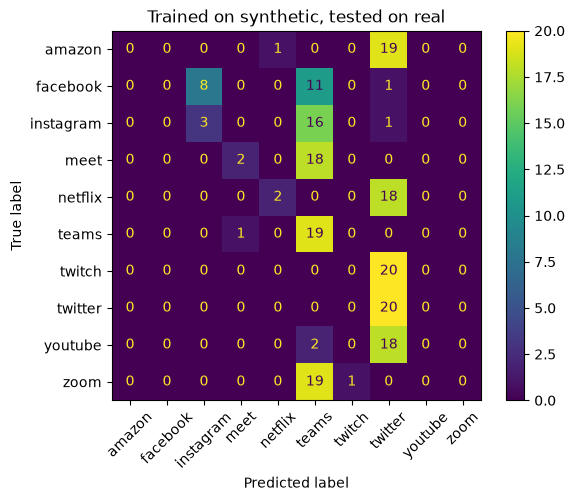

In [19]:
# Q7 step 2 — train on synthetic nPrints, evaluate on real nPrints.
clf_synth = RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1)
clf_synth.fit(X_synth, y_synth)
pred_real = clf_synth.predict(X_real)

acc_synth_to_real = accuracy_score(y_real, pred_real)
print(f"Train synthetic -> test real, accuracy: {acc_synth_to_real:.3f}\n")
print(classification_report(y_real, pred_real, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_real, pred_real, xticks_rotation=45)
plt.title("Trained on synthetic, tested on real")
plt.show()


Train real -> test synthetic, accuracy: 0.240

              precision    recall  f1-score   support

      amazon       0.00      0.00      0.00        10
    facebook       0.00      0.00      0.00        10
   instagram       0.00      0.00      0.00        10
        meet       0.32      1.00      0.49        10
     netflix       0.75      0.30      0.43        10
       teams       0.00      0.00      0.00        10
      twitch       0.00      0.00      0.00        10
     twitter       0.00      0.00      0.00        10
     youtube       0.29      0.50      0.37        10
        zoom       0.12      0.60      0.21        10

    accuracy                           0.24       100
   macro avg       0.15      0.24      0.15       100
weighted avg       0.15      0.24      0.15       100



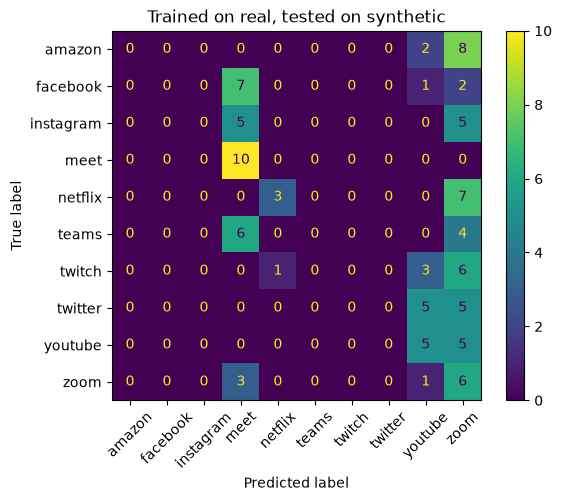

In [20]:
# Q7 step 3 — the opposite direction from the numbered list: train on real nPrints, evaluate on synthetic ones.
clf_real = RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1)
clf_real.fit(X_real, y_real)
pred_synth = clf_real.predict(X_synth)

acc_real_to_synth = accuracy_score(y_synth, pred_synth)
print(f"Train real -> test synthetic, accuracy: {acc_real_to_synth:.3f}\n")
print(classification_report(y_synth, pred_synth, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_synth, pred_synth, xticks_rotation=45)
plt.title("Trained on real, tested on synthetic")
plt.show()


In [21]:
# Q7 step 4 — put the numbers in context.
# Baseline: real -> real with 5-fold cross-validation shows how separable the apps are from 3 packets at all.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
acc_real_cv = cross_val_score(RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1),
                              X_real, y_real, cv=cv).mean()

print(pd.Series({"train synthetic -> test real": acc_synth_to_real,
                 "train real -> test synthetic": acc_real_to_synth,
                 "real -> real (5-fold CV baseline)": acc_real_cv,
                 "chance (10 balanced apps)": 1 / len(np.unique(y_real))}, name="accuracy").round(3).to_string())

# Which header bits does the synthetic-trained model rely on? (as in the nPrint lecture's "Understanding the Model")
importances = pd.Series(clf_synth.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop 15 features of the synthetic-trained model:")
print(importances.head(15).round(4).to_string())


train synthetic -> test real         0.230
train real -> test synthetic         0.240
real -> real (5-fold CV baseline)    0.945
chance (10 balanced apps)            0.100

Top 15 features of the synthetic-trained model:
pkt2_ipv4_id_15     0.0068
pkt1_ipv4_id_10     0.0065
pkt1_ipv4_ver_1     0.0062
pkt3_ipv4_id_9      0.0056
pkt1_ipv4_id_11     0.0051
pkt2_ipv4_id_11     0.0049
pkt2_ipv4_id_9      0.0047
pkt1_ipv4_hl_1      0.0047
pkt2_ipv4_id_2      0.0045
pkt1_ipv4_tl_11     0.0044
pkt1_ipv4_id_2      0.0042
pkt1_tcp_ackn_23    0.0039
pkt2_ipv4_id_4      0.0038
pkt3_tcp_ackn_23    0.0038
pkt1_ipv4_id_1      0.0038


**Q7 answer**

The question asks for opposite directions in two places, so I ran both, plus a real-only baseline. Each sample is its first 3 packets flattened into bit features, classified with a random forest.

| Setup | Accuracy |
|---|---|
| Train synthetic → test real | 0.230 |
| Train real → test synthetic | 0.240 |
| Real → real (5-fold CV) | 0.945 |
| Chance | 0.100 |

Across domains the classifier is only slightly better than chance, even though three real packets identify the app 94.5% of the time. The synthetic data keeps coarse structure, and the synthetic-trained model essentially learns only TCP apps versus UDP apps. It does not keep the bit-level patterns that distinguish apps, and with only 45 unique synthetic samples the model fits noise. These synthetic nPrints cannot replace real data for this task.
